# RNN으로 넷플릭스 주가 예측

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.optim.adam import Adam
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

df = pd.read_csv('../data/csv/NFLX.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5422 entries, 0 to 5421
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       5422 non-null   str    
 1   Open       5422 non-null   float64
 2   High       5422 non-null   float64
 3   Low        5422 non-null   float64
 4   Close      5422 non-null   float64
 5   Adj Close  5422 non-null   float64
 6   Volume     5422 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 296.6 KB


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5422 entries, 0 to 5421
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5422 non-null   datetime64[us]
 1   Open       5422 non-null   float64       
 2   High       5422 non-null   float64       
 3   Low        5422 non-null   float64       
 4   Close      5422 non-null   float64       
 5   Adj Close  5422 non-null   float64       
 6   Volume     5422 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 296.6 KB


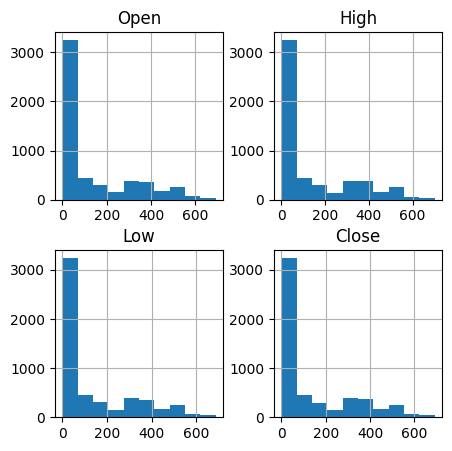

In [ ]:
data_used = df.iloc[:, 1:5]
hist = data_used.hist(figsize=(5, 5))
plt.show()

In [5]:
# 실제 금융 ML에서 가장 흔한 파이프라인:
# price
#  ↓
# log return
#  ↓
# standard scaler
#  ↓
# RNN/LSTM

# 또는

# price
#  ↓
# MinMaxScaler
#  ↓
# RNN

# 사실 RNN 주가 예측에서는
# return
# moving average
# volatility
# volume
# 와 같은 feature engineering이 더 중요함

In [ ]:
class Netflix(Dataset):
    def __init__(self):
        self.csv = pd.read_csv('../data/csv/NFLX.csv')

        self.df = self.csv.iloc[:, 1:5]

        for col in ['Open', 'High', 'Low', 'Close']:
            self.df[f'{col}_ret'] = np.log(self.df[col]).diff()

        self.data = self.df[['Open_ret', 'High_ret', 'Low_ret']].values
        self.label = self.df['Close_ret'].shift(-1).values

    def __len__(self):
        return len(self.data) - 30  # 사용 가능한 배치 개수

    def __getitem__(self, i):
        data = self.data[i : i + 30]
        label = self.label[i + 30]
        return data, label


class RNN(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.rnn = nn.RNN(input_size=3, hidden_size=8, num_layers=5, batch_first=True)

        self.fc1 = nn.Linear(in_features=240, out_features=64)
        self.fc2 = nn.Linear(in_features=64, out_features=1)

        self.relu = nn.ReLU()

    def forward(self, x, h0):
        x, hn = self.rnn(x, h0)

        # MLP층의 입력으로 사용되게 모양 변경
        x = torch.reshape(x, (x.shape[0], -1))

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        # 예측한 종가를 1차원 벡터로 표현
        x = torch.flatten(x)

        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RNN().to(device)
dataset = Netflix()

loader = DataLoader(dataset, batch_size=32)
optim = Adam(params=model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

for epoch in range(200):
    loop = tqdm(loader)

    running_loss = 0.0
    for data, label in loop:
        optim.zero_grad()

        h0 = torch.zeros(5, data.shape[0], 8).to(device)  # initial hidden state

        pred = model(data.type(torch.FloatTensor).to(device), h0)

        loss = criterion(pred, label.type(torch.FloatTensor).to(device))
        loss.backward()
        optim.step()

        loop.set_description(f'epoch:{epoch + 1} loss:{loss.item():.4f}')
    print(f'epoch {epoch + 1}  mean loss: {running_loss / len(loader):.4f}')

torch.save(model.state_dict(), '../data/models/rnn-NFLX.pth')

epoch:1 loss:nan: 100%|██████████| 169/169 [00:00<00:00, 328.74it/s]


epoch 1  mean loss: 0.0000


epoch:2 loss:nan: 100%|██████████| 169/169 [00:00<00:00, 407.23it/s]


epoch 2  mean loss: 0.0000


epoch:3 loss:nan: 100%|██████████| 169/169 [00:00<00:00, 397.57it/s]


...

epoch 198  mean loss: 0.0000


epoch:199 loss:nan: 100%|██████████| 169/169 [00:00<00:00, 411.82it/s]


epoch 199  mean loss: 0.0000


epoch:200 loss:nan: 100%|██████████| 169/169 [00:00<00:00, 417.47it/s]

epoch 200  mean loss: 0.0000


In [ ]:
loader = DataLoader(dataset, batch_size=1)

preds = []
total_loss = 0
criterion = nn.MSELoss()

with torch.no_grad():
    model.load_state_dict(
        torch.load('../data/models/rnn-NFLX.pth', map_location=device)
    )

    for data, label in loader:
        h0 = torch.zeros(5, data.shape[0], 8).to(device)

        pred = model(data.type(torch.FloatTensor).to(device), h0)
        preds.append(pred.item())

        loss = criterion(pred, label.type(torch.FloatTensor).to(device))

        total_loss += loss / len(loader)
print(total_loss.item())

nan


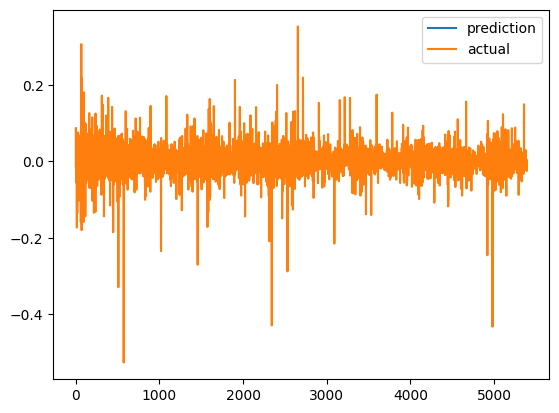

In [ ]:
plt.plot(preds, label='prediction')
plt.plot(dataset.label[30:], label='actual')
plt.legend()
plt.show()